# Lecture 14: Simulation Practice and the Monty Hall Problem
v.ekc

Today we cement the simulation recipe, and then use it to settle one of the most famously counterintuitive puzzles in probability. 🚪🚪🚪

**Today's sections:**
1. Advanced `where`, recapped
2. `for` statements, recapped
3. The dice game, end to end
4. Try It — coin tosses
5. The Monty Hall problem

In [1]:
from datascience import *
%matplotlib inline
path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np
import warnings
warnings.filterwarnings("ignore")

---
## 1. Advanced `where`, Recapped

An array of bools works as a filter directly. (This time our table has names, so the filtering is easier to see.)

In [2]:
names = make_array('John','Jane','Joe','Jerry','Jill','Jeff','Jim','Jamie')
ages = make_array(16, 22, 18, 15, 19, 15, 16, 21)
age = Table().with_columns('Name', names,
                           'Age', ages)

In [3]:
age

Name,Age
John,16
Jane,22
Joe,18
Jerry,15
Jill,19
Jeff,15
Jim,16
Jamie,21


In [4]:
age.where('Age', are.above_or_equal_to(18))

Name,Age
Jane,22
Joe,18
Jill,19
Jamie,21


The bool array *is* the filter:

In [5]:
voter = ages >= 18
voter

array([False,  True,  True, False,  True, False, False,  True], dtype=bool)

In [6]:
age.where(voter)

Name,Age
Jane,22
Joe,18
Jill,19
Jamie,21


### Try It 1: Too young to vote 🇺🇸

1. Using a **bool array** (not a predicate), filter `age` to the people who can't vote yet.

In [8]:
# 1. under-18 filter via bool array

# recall, the array `ages` which we used to build the table `age`

Name,Age
John,16
Jerry,15
Jeff,15
Jim,16


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Flip the comparison, the array does the rest.*

```python
# 1.
age.where(ages < 18)
```

</details>

---
## 2. `for` Statements, Recapped

The loop variable takes each value in turn, and remember, `np.append` does nothing unless you **reassign**. (KL deck, slides 5–6.)

In [9]:
for pet in make_array('cat', 'dog', 'rabbit', 'husband'):
    print('I love my ' + pet)

I love my cat
I love my dog
I love my rabbit
I love my husband


In [11]:
temporary = make_array('cat', 'dog', 'rabbit', 'husband')

pet = temporary.item(0)
print('I love my ' + pet)

pet = temporary.item(1)
print('I love my ' + pet)

pet = temporary.item(2)
print('I love my ' + pet)

pet = temporary.item(3)
print('I love my ' + pet)

I love my cat
I love my dog
I love my rabbit
I love my husband


The loop variable can be numbers, or something you never even use:

In [12]:
for i in np.arange(5):
    print(i)

0
1
2
3
4


In [13]:
for i in np.arange(5):
    print('DATA 111 is AWESOME!')

DATA 111 is AWESOME!
DATA 111 is AWESOME!
DATA 111 is AWESOME!
DATA 111 is AWESOME!
DATA 111 is AWESOME!


And the append-reassign common mistake.....:

In [14]:
s = make_array(2, 3)
np.append(s, 4)
s

array([2, 3])

In [ ]:
s + 3
s

In [ ]:
s = np.append(s, 4)
s

### Try It 2: Loop reps 😊

1. Write a loop that prints the **square** of each number 0 through 4.

2. Use the append pattern to build an array of the first five powers of 2 (1, 2, 4, 8, 16).

In [16]:
# 1. print squares

for i in np.arange(5):
    print(i**2)

0
1
4
9
16


In [20]:
# 2. powers of 2

powers = make_array()

for i in np.arange(5):
    powers = np.append(powers, 2**i)

powers

array([  1.,   2.,   4.,   8.,  16.])

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Start empty, append once per pass, reassign every time.*

```python
# 1.
for i in np.arange(5):
    print(i ** 2)

# 2.
powers = make_array()
for i in np.arange(5):
    powers = np.append(powers, 2 ** i)
powers
```

</details>

---
## 3. The Dice Game, End to End

The whole recipe in three cells: one round → one simulated round → over 9,000!

In [21]:
def one_round(my_roll, your_roll):
    if my_roll > your_roll:
        return 1
    elif your_roll > my_roll:
        return -1
    else:
        return 0

In [22]:
def simulate_one_round():
    my_roll = np.random.choice(np.arange(1,7))
    your_roll = np.random.choice(np.arange(1,7))
    return one_round(my_roll,your_roll)

Ten thousand games, then the verdict:

In [23]:
game_outcomes = make_array()

for i in np.arange(10000):
    game_outcomes = np.append(game_outcomes, simulate_one_round())
    
game_outcomes

array([-1.,  0.,  1., ...,  1.,  0.,  0.])

In [24]:
sum(game_outcomes)

-5.0

Table + group + chart, as always:

In [25]:
results = Table().with_column('My winnings', game_outcomes)
results

My winnings
-1
0
1
-1
-1
0
0
1
1
1


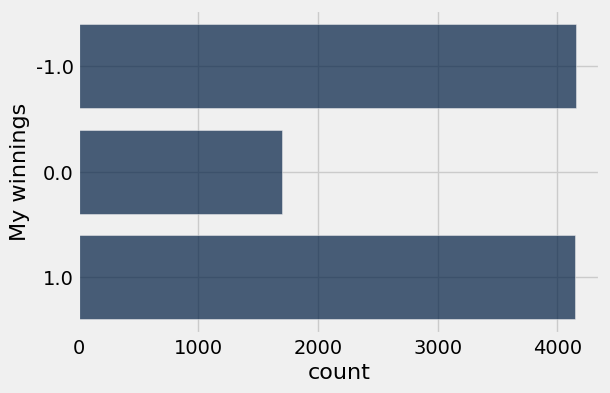

In [26]:
results.group('My winnings').barh('My winnings')

### Try It 3: Rig the game 😊

1. Change the rules so **ties pay you** a dollar (+1 instead of 0). Re-simulate 10,000 games, about how much do you win overall now?

2. Roughly why does that number make sense? (How often do ties happen?)

In [ ]:
# 1. rigged game, 10,000 rounds




*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Only the final branch changes, then the same recipe runs.*

```python
# 1.
def one_round_rigged(my_roll, your_roll):
    if my_roll > your_roll:
        return 1
    elif your_roll > my_roll:
        return -1
    else:
        return 1

rigged = make_array()
for i in np.arange(10000):
    rigged = np.append(rigged, one_round_rigged(np.random.choice(np.arange(1, 7)), np.random.choice(np.arange(1, 7))))
sum(rigged)
```

*2. Ties happen about 1/6 of the time, and each now hands you \$1, so ≈ 10000/6 ≈ \$1,700 ahead.*

</details>

---
### Try It 4: 100 coin tosses, again 🪙

(Repetition is the point, this pattern should become automatic.)

1. Make the `coin` array.

2. Simulate a coin toss 100 times.

3. Count the heads in your 100 tosses.

In [ ]:
# Fill in the blank: 
coin = ...

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Same as Lecture 13, if you didn't need the peek this time, it's working.*

```python
# 1.
coin = make_array('heads', 'tails')

# 2.
np.random.choice(coin, 100)

# 3.
sum(np.random.choice(coin, 100) == 'heads')
```

</details>

Checkpoint, run this, then the full pipeline for reference:

In [ ]:
# run me: needed below
coin = make_array('heads', 'tails')

In [ ]:
# Simulate one outcome
def num_heads():
    return sum(np.random.choice(coin, 100) == 'heads')

In [ ]:
# Decide how many times you want to repeat the experiment
repetitions = 10000

In [ ]:
# Simulate that many outcomes
outcomes = make_array()

for i in np.arange(repetitions):
    outcomes = np.append(outcomes, num_heads())

In [ ]:
heads = Table().with_column('Heads', outcomes)
heads.hist(bins = np.arange(29.5, 70.6))

---
## 4. The Monty Hall Problem 🚪🐐🚗🐐

Three doors: one car, two goats. You pick a door; Monty (who knows where the car is) opens a *different* door revealing a goat, and offers you a switch. **Stay or switch?** Marilyn vos Savant said switch and thousands of PhDs wrote in to call her wrong. Let's simulate instead of arguing.

In [98]:
goats = make_array('🐐1️⃣', '🐐2️⃣')

In [99]:
def other_goat(x):
    if x == '🐐1️⃣':
        return '🐐2️⃣'
    elif x == '🐐2️⃣':
        return '🐐1️⃣'

In [100]:
[other_goat('🐐1️⃣'), other_goat('🐐2️⃣')]

['🐐2️⃣', '🐐1️⃣']

All three doors in one array:

In [101]:
hidden_behind_doors = np.append(goats, '🚗')
hidden_behind_doors

array(['🐐1️⃣', '🐐2️⃣', '🚗'],
      dtype='<U4')

The whole game in one function: guess, reveal, what remains:

In [102]:
def monty_hall_game():

    """Return 
    [contestant's guess, what Monty reveals, what remains behind the other door]"""
    
    contestant_guess = np.random.choice(hidden_behind_doors)   # you pick at random from ['first goat','second goat','car']

    if contestant_guess == '🐐1️⃣':
        return [contestant_guess, '🐐2️⃣', '🚗']        # row 1: Monty has to show goat 2; car remains

    if contestant_guess == '🐐2️⃣':
        return [contestant_guess, '🐐1️⃣', '🚗']        # row 2: Monty has to show goat 1; car remains

    if contestant_guess == '🚗':
        goats = make_array('🐐1️⃣', '🐐2️⃣')
        revealed = np.random.choice(goats)             # row 3: Monty can show either goat, so pick one at random
                                                       #        and the other goat is what remains
    return [contestant_guess, revealed, other_goat(revealed)]

In [103]:
monty_hall_game()

['🚗', '🐐2️⃣', '🐐1️⃣']

Play 10,000 games, appending each result as a table **row**:

In [104]:
games = Table(['Guess', 'Revealed', 'Remaining'])

for i in np.arange(10000):
    games.append(monty_hall_game())

In [105]:
games.show(10)

Guess,Revealed,Remaining
🚗,🐐2️⃣,🐐1️⃣
🐐2️⃣,🐐1️⃣,🚗
🚗,🐐2️⃣,🐐1️⃣
🐐2️⃣,🐐1️⃣,🚗
🐐1️⃣,🐐2️⃣,🚗
🚗,🐐2️⃣,🐐1️⃣
🐐1️⃣,🐐2️⃣,🚗
🚗,🐐2️⃣,🐐1️⃣
🐐1️⃣,🐐2️⃣,🚗
🚗,🐐1️⃣,🐐2️⃣


Group both columns to see where the car ended up:

In [106]:
original_choice = games.group('Guess')
original_choice

Guess,count
🐐1️⃣,3274
🐐2️⃣,3372
🚗,3354


In [107]:
remaining_door = games.group('Remaining')
remaining_door

Remaining,count
🐐1️⃣,1665
🐐2️⃣,1689
🚗,6646


Join into one summary table and chart it:

In [108]:
joined = original_choice.join('Guess', remaining_door, 'Remaining')
combined = joined.relabeled(0, 'Item').relabeled(1, 'Original Door').relabeled(2, 'Remaining Door')
combined

Item,Original Door,Remaining Door
🐐1️⃣,3274,1665
🐐2️⃣,3372,1689
🚗,3354,6646


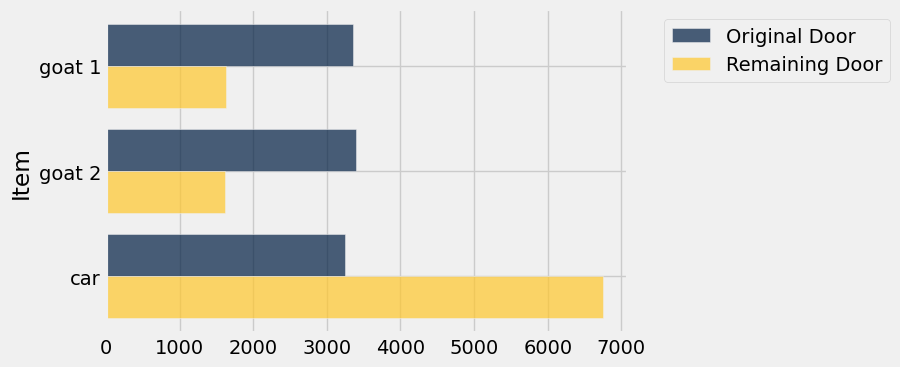

In [97]:
# change '🐐1️⃣' > 'goat 1'
# change '🐐2️⃣' > 'goat 2'
# change '🚗' > 'car'
#    reason: the emoji's don't show up in the bar labels :(
combined['Item'] = make_array('goat 1', 'goat 2', 'car')

# plot!
combined.barh(0)

### Try It 5: Stay or switch? 🐐🐐🐐🐐🐐🐐🐐🐐🐐🐐🐐

1. Straight from the `games` table: in what **proportion** of the 10,000 games is the car behind the *Remaining* door?

2. Your verdict, in one sentence.

In [ ]:
# 1. proportion with car behind Remaining


*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*One `where`, one division.*

```python
# 1.
games.where('Remaining', 'car').num_rows / games.num_rows
```

*2. About 2/3, so switch: your first pick is wrong two times out of three, and switching wins every one of those.*

</details>

> **The verdict:** the car ends up behind the *other* door about 2/3 of the time: switching doubles your chances. Your first pick is wrong 2/3 of the time, and whenever it's wrong, switching wins. Simulation proves itttt! 🏆

---
> **Today's takeaway:** the simulation recipe is now muscle memory, and it just resolved a puzzle that fooled thousands of mathematicians. Homework 5's roulette section is this exact pattern.

## Appendix — Quick Reference

Full `datascience` docs: [data8.org/datascience](https://data8.org/datascience/)

### The simulation recipe (memorize me)
```python
def one_outcome():
    return ...

outcomes = make_array()
for i in np.arange(10000):
    outcomes = np.append(outcomes, one_outcome())
```